In [ ]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch.nn as nn
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(device)

cuda


In [ ]:
df = pd.read_csv("/content/fashion-mnist_train.csv")

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

In [ ]:
X = df.iloc[:, 1 :].values
y = df.iloc[:, 0 ].values

In [ ]:
X_train, x_test, y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
x_test = x_test/255.0

# as we were intially passing 784 pixels in a single straight tensor 1d now as in cnn we need to make it 2d so we have to : rehsape it to 2d (28 , 28)

In [ ]:
class dataset_define(Dataset):
  def __init__(self, n_features, labels):
    self.n_features = torch.tensor(n_features, dtype=torch.float32).reshape(-1,1, 28,28) # -1 is placeholder for batchsize/ row size
    self.labels = torch.tensor(labels, dtype=torch.long)


  def __len__(self):
    return len(self.n_features)

  def __getitem__(self, index):
    return self.n_features[index] , self.labels[index]

In [ ]:
train_dataset = dataset_define(X_train, y_train)
test_dataset = dataset_define(x_test, y_test )

In [ ]:
train_data_loader = DataLoader(train_dataset , batch_size=32, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

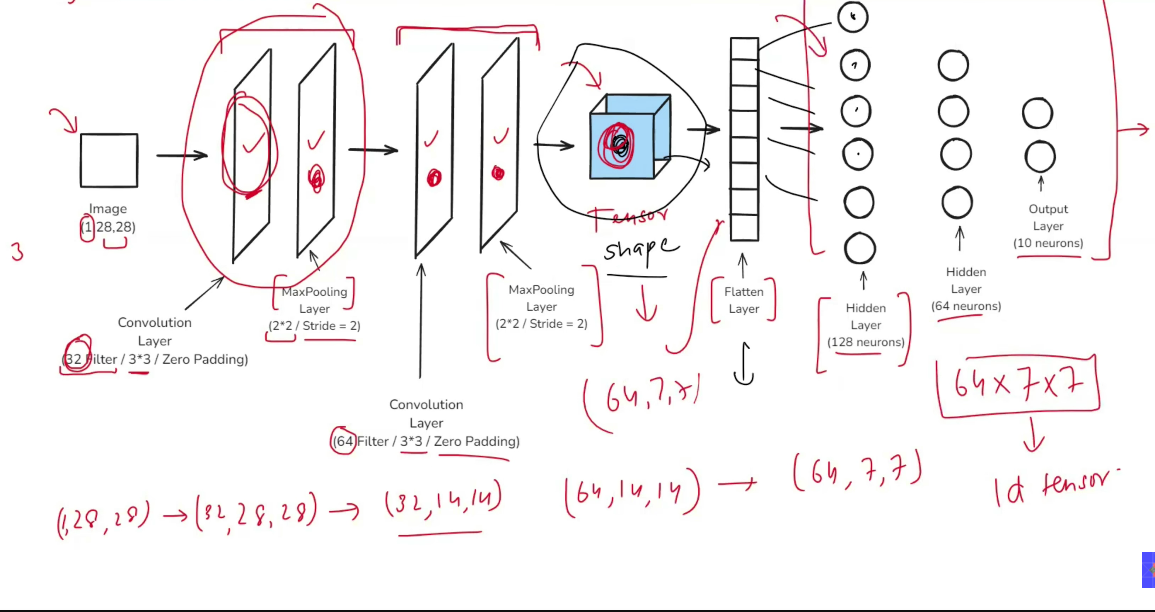

In [ ]:

class define_neural_network(nn.Module):
  def __init__(self,input_features):

    super().__init__()


    self.feature_ext = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'), # input, out_channels/filters, kernel_size, padding
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),


        nn.Conv2d(32, 64, kernel_size=3, padding='same'), # input, out_channels/filters, kernel_size, padding
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )


    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64, 10)
    )



  def forward(self, x):
    x = self.feature_ext(x)
    x = self.classifier(x)
    return x



In [ ]:
learning_rate=0.01
epoches = 30

In [ ]:
model = define_neural_network(1)

In [ ]:
model.to(device)

define_neural_network(
  (feature_ext): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
loss = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [ ]:
for epoch in range(epoches):

  total_epoch_loss = 0


  for feature_batch , labels_batch in train_data_loader:

    feature_batch , labels_batch = feature_batch.to(device) , labels_batch.to(device)

    # forward pass

    outputs = model(feature_batch.float())

    # loss

    lossed = loss(outputs, labels_batch)

    # optimize

    optimizer.zero_grad()

    lossed.backward()

    # update grads

    optimizer.step()

    total_epoch_loss = total_epoch_loss + lossed.item()

  avg_loss = total_epoch_loss/len(train_data_loader)
  print(f"Epoch : {epoch + 1 } , and average loss : {avg_loss}")


Epoch : 1 , and average loss : 0.6493636162380377
Epoch : 2 , and average loss : 0.3850801167488098
Epoch : 3 , and average loss : 0.31840807520598174
Epoch : 4 , and average loss : 0.2846437230532368
Epoch : 5 , and average loss : 0.26097652420649925
Epoch : 6 , and average loss : 0.23923493442808588
Epoch : 7 , and average loss : 0.2260821899175644
Epoch : 8 , and average loss : 0.21045091223095855
Epoch : 9 , and average loss : 0.19688920607231558
Epoch : 10 , and average loss : 0.18382938467959564
Epoch : 11 , and average loss : 0.17735965100862086
Epoch : 12 , and average loss : 0.1618902858560905
Epoch : 13 , and average loss : 0.15693588263106842
Epoch : 14 , and average loss : 0.14536011493516465
Epoch : 15 , and average loss : 0.1387157605284204
Epoch : 16 , and average loss : 0.13017047163719933
Epoch : 17 , and average loss : 0.12184665870806202
Epoch : 18 , and average loss : 0.11767291163404782
Epoch : 19 , and average loss : 0.1110093860354585
Epoch : 20 , and average los

In [ ]:
model.eval()

define_neural_network(
  (feature_ext): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
correct = 0
total = 0

with torch.no_grad():

  for batch_features , batch_labels in train_data_loader:

    batch_features , batch_labels = batch_features.to(device) , batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    _, predicted = torch.max(outputs , 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

  print(f"model accuracy : { correct/total * 100 } %")

model accuracy : 99.20416666666667 %


In [ ]:
correct = 0
total = 0

In [1]:
with torch.no_grad():

  for batch_features , batch_labels in test_data_loader:

    batch_features , batch_labels = batch_features.to(device) , batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    _, predicted = torch.max(outputs , 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

  print(f"model accuracy : { correct/total * 100 } %")


NameError: name 'torch' is not defined